In [2]:
# If needed (run once)
# !pip install textblob vaderSentiment seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_style("whitegrid")

## 3. 1. Load and clean comments

In [4]:
df = pd.read_csv(r"C:\Users\hp\Downloads\project DS\Sentiment_analysis(YT)\YouTube Comments Dataset with Sentiment Toxicity and Spam Labels (45K Rows).csv")
print(df.head())
print(df.info())

# Keep only needed column 
# Adjust column name based on the CSV
TEXT_COL = "comment_text"  # change this if your CSV column is different
df = df[[TEXT_COL]].dropna()

# 1.3 Simple cleaning (remove empty/whitespace)
df[TEXT_COL] = df[TEXT_COL].str.strip()
df = df[df[TEXT_COL] != ""]
print(f"Number of comments: {len(df)}")

  channel_username                channel_id     video_id  \
0             @WWE  UCJ5v_MCY6GNUBTO8-D3XoAg  wj56SBaroCE   
1           @ZeeTV  UCppHT7SZKKvar4Oc9J4oljQ  3KWNKzs_ptQ   
2        @ColorsTV  UC55IWqFLDH1Xp7iu1_xknRA  eqwlbP4f4G4   
3       @김프로KIMPRO  UCiVs2pnGW5mLIc1jS2nxhjg  R_gAdQqH6gA   
4        @ColorsTV  UC55IWqFLDH1Xp7iu1_xknRA  g2pWwrK2fyE   

                                         video_title  \
0  Jade Cargill continues to perform knowing the ...   
1  Tum Se Tum Tak - तुम से तुम तक - 7th July Onwa...   
2  Laughter Chefs S2 | Full Episode - 41 | India ...   
3                   Perfect Featuring | First Take🎬🤣   
4  Meri Bhavya Life | Ep. 55 | Uma Requests Risha...   

                                        comment_text  \
0  Jade was pushed fast in another company. WWE i...   
1  Are ye 20 sal mushki se jiye ga tab ladki bewa...   
2  Aly is fcking rude for no reason its laughter ...   
3                     Aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa   
4  bhavya is fur

## 4. 2. Sentiment with TextBlob

In [7]:
# Function to get TextBlob sentiment
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    if pol > 0.1:
        return "Positive"
    elif pol < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Apply TextBlob
df["textblob_sentiment"] = df[TEXT_COL].apply(get_textblob_sentiment)

# Check distribution
print(df["textblob_sentiment"].value_counts())

textblob_sentiment
Neutral     34427
Positive     8623
Negative     1950
Name: count, dtype: int64


## Using VADAR

In [6]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    comp = scores["compound"]
    if comp >= 0.05:
        return "Positive"
    elif comp <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply VADER
df["vader_sentiment"] = df[TEXT_COL].apply(get_vader_sentiment)

# Compare distributions
print("TextBlob:")
print(df["textblob_sentiment"].value_counts())

print("\nVADER:")
print(df["vader_sentiment"].value_counts())

TextBlob:
textblob_sentiment
Neutral     34427
Positive     8623
Negative     1950
Name: count, dtype: int64

VADER:
vader_sentiment
Positive    20810
Neutral     19418
Negative     4772
Name: count, dtype: int64


## Insights and visualizations

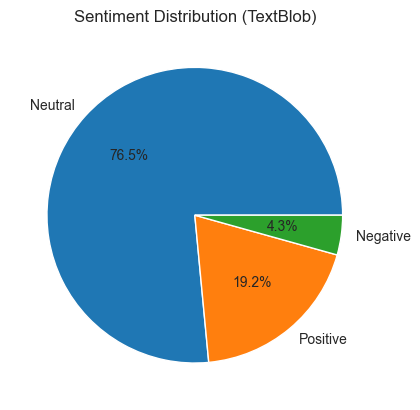

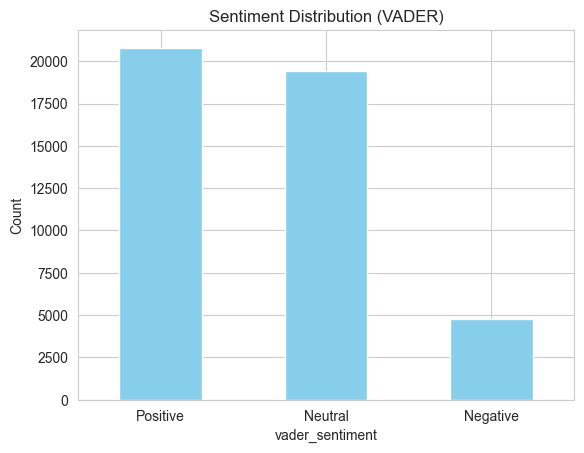

Top 5 positive comments:
['Jade was pushed fast in another company. WWE is treating her right. She has the look, she has the skills, she has the ability. Some people just don’t want to see talent succeed. Nothing to do with being a female, colour of skin. They just don’t like to see someone strong and confident succeed.'
 'I love that she licked her!' "Sunoo's soo freaking beautiful here"
 'This is dumb.. first of all it won’t protect you from the rain and what’s pissing me off the most IS YOU RIPPING THE UMBRELLA. WHY??'
 "Damn. Asuka's english hace gotten so much better"]


In [9]:
# Pie chart: TextBlob sentiment
df["textblob_sentiment"].value_counts().plot(
    kind="pie", autopct="%.1f%%", title="Sentiment Distribution (TextBlob)"
)
plt.ylabel("")
plt.show()

# Bar chart: VADER sentiment
df["vader_sentiment"].value_counts().plot(
    kind="bar", title="Sentiment Distribution (VADER)", color="skyblue"
)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Top 5 most positive comments (TextBlob)
positive = df[df["textblob_sentiment"] == "Positive"]
print("Top 5 positive comments:")
print(positive[TEXT_COL].head(5).values)

# Summary and Insights

- Most comments are **neutral**, but a large share is **positive**.
- Negative comments are relatively rare, which may indicate that people mostly engage with liked or interesting videos.
- TextBlob and VADER show similar overall trends but may differ on specific examples.